# FIE463 Term Paper 1 - Group 6

## Course Information
**Course:** Numerical Methods in Macroeconomics and Finance using Python  
**Instructor:** Richard Foltyn  

## Submission Details
**Candidate Numbers:** [114, 117, 129]  
**Submission Date:** March 17, 2025  


## AI statement
The work was done independently, with AI (ChatGPT) used only for general refinements, specifically making the plots more presentable and fixing typos and syntax errors in the code.

## Packages and declaration

In [1]:
# Import necessary libraries
import numpy as np
from numpy.polynomial.hermite_e import hermegauss
from dataclasses import dataclass
from scipy.optimize import root_scalar
from numpy.polynomial.hermite_e import hermegauss
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

The following resources were utilized:
- Lecture notes and code examples from the FIE463 GitHub repository
- Official NumPy and SciPy documentation for optimization and vectorization techniques
- Methods and concepts learned from previous coursework, including BAN401

## Part 1: Euler Equation Errors


The task is to compute Euler equation errors to verify whether the household’s savings decision satisfies intertemporal optimality. This ensures the model correctly determines equilibrium capital.

### Step 1: Define the parameters Data Class

We define the parameters class with the necessary attributes.

In [2]:
@dataclass
class Parameters:
    """
    Store model parameters with 30-year period values
    """
    β: float = 0.96**30       # Discount factor
    γ: float = 5.0            # Risk aversion
    α: float = 0.36           # Capital share
    δ: float = 1 - 0.94**30   # Depreciation rate
    z: float = 1.0            # TFP
    tau: float = 0.0          # Payroll tax

    # AR(1) Process for TFP
    rho: float = None         # Place-holder for later
    sigma2: float = None      # Place-holder for later
    mu: float = None          # Place-holder for later

# Initialize parameters
par = Parameters()

### Step 2: Implementing euler_err() function

We start by defining a helper function for computing factor prices using the firm's first order conditions.

In [3]:
def compute_prices(k, par: Parameters):
    """
    Return factor prices for a given capital-labor ratio and parameters.
    """
    # Return on capital after depreciation (interest rate)
    r = par.α * par.z * k**(par.α - 1) - par.δ

    # Wage rate
    w = (1 - par.α) * par.z * k**par.α

    return r, w

Now we can implement the euler_err() function. The function computes the Euler equation error given capital today (k) and capital tomorrow (k_next)

In [4]:
def euler_err(k_next, k, par: Parameters):
    """
    Compute the Euler equation error for a given capital stock today and tomorrow.
    """

    # Compute factor prices for current and next period
    r_current, w_current = compute_prices(k, par)
    r_next, w_next = compute_prices(k_next, par)

    # Define pension payment
    p_next = par.tau * w_next # Pensions in t+1 are funded by young in t+1

    # Compute consumption for young ald old
    c_young = (1 - par.tau) * w_current - k_next
    c_old = (1 + r_next) * k_next + p_next # Old in t+1 consume savings from t plus pensions funded by young in t+1

    # We reject solutions where consumption is negative
    if c_young < 0 or c_old < 0:
        return np.inf

    # Compute marginal utilities
    # (If consumption is 0, we set marginal utility to a very high value)
    if par.γ == 1:
        mu_young = 1 / c_young if c_young > 0 else np.inf  # Log utility case
        mu_old = 1 / c_old if c_old > 0 else np.inf
    else:
        mu_young = c_young ** (-par.γ) if c_young > 0 else np.inf
        mu_old = c_old ** (-par.γ) if c_old > 0 else np.inf

    # Return euler equation error
    return mu_young - par.β * (1 + r_next) * mu_old


### Step 3: Plot the Euler equation error

To examine the behavior of the Euler equation, we evaluate errors over a grid of capital values $ k \in [0.05, 0.2] $.

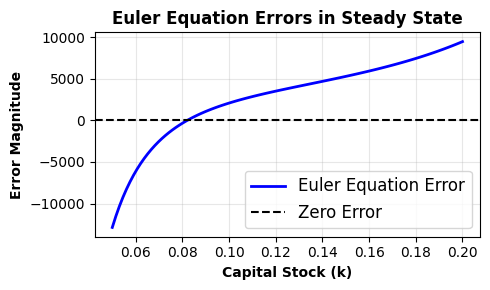

In [5]:
# Create capital grid
k_grid = np.linspace(0.05, 0.2, 100)

# Calculate errors assuming k_{t+1} = k_t = k
errors = [euler_err(k, k, par) for k in k_grid]

# Plot results with a larger figure size
plt.figure(figsize=(5, 3))  # Increased width and height for better readability
plt.plot(k_grid, errors, label='Euler Equation Error', color='b', linewidth=2)
plt.axhline(0, color='k', linestyle='--', label='Zero Error')
plt.title('Euler Equation Errors in Steady State', fontsize=12, fontweight='bold')
plt.xlabel('Capital Stock (k)', fontsize=10, fontweight='bold')
plt.ylabel('Error Magnitude', fontsize=10, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



The plot illustrates how the Euler equation error varies with capital. The steady-state capital level is found where the error equals zero, ensuring the intertemporal condition is satisfied. This occurs at the intersection of the blue curve and the dashed line, indicating the capital level where households optimally allocate savings and consumption.


## Part 2: Steady State Computation


In this section, we compute the steady-state equilibrium of the economy, where all quantities and prices remain constant over time. The steady-state condition requires that the capital stock remains unchanged across periods:

$$ k^* = k_{t+1} = k_t $$

At equilibrium, the Euler equation error should be zero:

$$ euler\_err(k^*, k^*, par) = 0 $$




### Step 1: Defining the `SteadyState` Data Class

In [6]:
@dataclass
class SteadyState:
    """
    Store steady-state equilibrium values.
    """
    K: float = None    # Capital stock
    Y: float = None    # Output
    w: float = None    # Wage rate
    r: float = None    # Interest rate
    c_y: float = None  # Young consumption
    c_o: float = None  # Old consumption
    s: float = None    # Savings rate
    a: float = None    # Savings when young
    p: float = None     # Pension payment


### Step 2: Implementing `compute_steady_state()`

We solve for the steady-state capital stock k using root-finding on the Euler equation.

In [7]:
def compute_steady_state(par: Parameters):
    """
    Compute steady state using root-finding on Euler equation.
    """
    try:
        # Find the steady-state capital stock such that the Euler equation holds
        result = root_scalar(lambda k: euler_err(k, k, par), bracket=(1e-8, 2.0), method='brentq')

        # Ensure root-finding converged
        if not result.converged:
            raise RuntimeError("Root-finding for steady-state capital did not converge.")

        # Store the results from root-finder in K_eq s
        K_eq = result.root

    except ValueError as e:
        raise RuntimeError("Root-finding failed for steady-state capital.") from e

    # Compute steady-state factor prices
    r_eq, w_eq = compute_prices(K_eq, par)

    # Compute steady-state output
    Y_eq = par.z * (K_eq**par.α)

    # Compute pension payment recieved by the old in steady state
    p_eq = par.tau * w_eq

    # Set the steady-state vaule of savings when young equal to K_eq
    a_eq = K_eq

    # Compute steady-state consumption and ensure it is non-negative
    c_y_eq = np.maximum((1 - par.tau) * w_eq - a_eq, 0)
    c_o_eq = np.maximum((1 + r_eq) * a_eq + p_eq, 0)

    # Compute steady-state savings rate and ensure no division by zero
    s_eq = np.where(w_eq > 0, a_eq / ((1 - par.tau) * w_eq), 0.0)

    # Goods Market Clearing Condition
    lhs = Y_eq + (1 - par.δ) * K_eq
    rhs = c_y_eq + c_o_eq + a_eq
    assert abs(lhs - rhs) < 1e-8, f"Goods market clearing fails: {lhs} != {rhs}"


    # Return the steady-state values
    return SteadyState(K = K_eq, Y = Y_eq, w = w_eq, r = r_eq, c_y = c_y_eq, c_o = c_o_eq, s = s_eq, a = a_eq, p = p_eq)

### Step 3: Implementing `print_steady_state()` to Print Results



In [8]:
def print_steady_state(eq: SteadyState):
    """
    Display steady-state results in readable format.
    """

    print("="*42)
    print("       STEADY STATE EQUILIBRIUM       ")
    print("="*42)
    print(f"{'Capital (K):':<25}{eq.K:>16.4f}")
    print(f"{'Output (Y):':<25}{eq.Y:>16.4f}")
    print(f"{'Wage (w):':<25}{eq.w:>16.4f}")
    print(f"{'Interest rate (r):':<25}{eq.r:>16.4f}")
    print(f"{'Young consumption (c_y):':<25}{eq.c_y:>16.4f}")
    print(f"{'Old consumption (c_o):':<25}{eq.c_o:>16.4f}")
    print(f"{'Savings rate (s):':<25}{eq.s:>16.4f}")
    print(f"{'Savings when young (a):':<25}{eq.a:>16.4f}")
    print("="*42)

### Step 4: Display the Steady-State Equilibrium

In [9]:
# Compute the steady-state equilibrium given the parameters
eq = compute_steady_state(par)
# Print the computed steady-state values
print_steady_state(eq)

       STEADY STATE EQUILIBRIUM       
Capital (K):                       0.0821
Output (Y):                        0.4065
Wage (w):                          0.2602
Interest rate (r):                 0.9396
Young consumption (c_y):           0.1781
Old consumption (c_o):             0.1592
Savings rate (s):                  0.3154
Savings when young (a):            0.0821


The steady-state equilibrium represents the long-run condition where economic variables stabilize, ensuring efficient allocation of resources, market clearing, and optimal firm pricing according to marginal productivity theory.

At equilibrium, the capital stock $K$ reflects the balance between household savings and firm investment, maintaining a stable capital-labor ratio. A higher capital stock lowers interest rates, discouraging saving, while a lower capital stock increases interest rates, incentivizing more savings. The steady-state interest rate $r$ indicates capital scarcity, leading to high returns on savings and reinforcing the intertemporal trade-off between current and future consumption.

Wages $w$ are determined by labor’s marginal productivity, shaping young households' income. Since households must save for retirement, they allocate $ c_y$ for consumption and $a$ for future use, ensuring sufficient old-age consumption of $c_o$. The 31.54% savings rate reflects precautionary motives and the necessity of accumulating wealth for future consumption.

Total output $Y$, derived from the Cobb-Douglas production function, is fully allocated between consumption and investment, ensuring the goods market clears. The validity of the Euler equation confirms that households optimally allocate resources across periods, balancing the marginal utility of consumption today against expected returns in the future. This ensures dynamic efficiency, meaning no reallocation of capital could improve overall welfare.


## Part 3: Transition dynamics

In this section, we examine the economy’s behavior when it is temporarily displaced from its steady-state equilibrium.
The transition dynamics describe how capital, wages, interest rates, and savings evolve over time following an
unexpected shock.

### Step 1: Create a Simulation Data Class

To systematically store the simulated time series of key macroeconomic variables, we define a Simulation data class.

In [10]:
# Create a Sim data class
@dataclass
class Simulation:
    """
    Store simulation results for transition dynamics
    """

    K: float = None     # Capital stock path
    Y: float = None     # Output path
    w: float = None     # Wage path
    r: float = None     # Interest rate path
    c_y: float = None   # Young consumption path
    c_o: float = None   # Old consumption path
    a: float = None     # Savings path
    s: float = None     # Savings rate path
    p: float = None     # Pension payment path

### Step 2: Implement simulate_olg() to Compute the Transition Path

The function simulate_olg() computes the transition path by solving for $K_{t+1}$ using the Euler equation and a root-finder. It ensures optimal intertemporal consumption and verifies goods market clearing for equilibrium consistency.

In [11]:
def simulate_olg(K1, T, eq: SteadyState, par: Parameters):
    """
    Simulate the transition dynamics of the OLG model starting from steady state
    when a shock to capital realizes in period 1.
    """
    # Initialize arrays
    K, Y, w, r, a, c_y, c_o, s, p = (np.zeros(T+1) for _ in range(9))

    # Set steady-state values (t=0)
    K[0], Y[0], w[0], r[0], a[0], c_y[0], c_o[0], s[0], p[0] = eq.K, eq.Y, eq.w, eq.r, eq.a, eq.c_y, eq.c_o, eq.s, eq.p

    # Apply shock at t=1
    K[1] = K1

    # Compute output in t = 1
    Y[1] = par.z * (K[1] ** par.α)

    # Compute factor frices in t = 1
    r[1], w[1] = compute_prices(K[1], par)

    # Compute pension payment in t = 1
    p[1] = par.tau * w[1]

    # Solve Euler equation for K2 (a[1])
    try:
        res = root_scalar(lambda k_next: euler_err(k_next, K[1], par), bracket=(1e-8, w[1]), method='brentq')
        a[1] = res.root
    except ValueError as e:
        raise RuntimeError(f"Root-finding failed at t=1, K_t={K[1]}, w_t={w[1]}") from e

    K[2] = a[1]

    # Compute consumption and and ensure it is non-negative
    c_y[1] = np.maximum((1 - par.tau) * w[1] - a[1], 0)
    c_o[1] = np.maximum((1 + r[1]) * K[1] + p[1], 0)

    # Compute savings and avoid potential division by 0
    s[1] = np.where(w[1] > 0, a[1] / ((1 - par.tau) * w[1]), 0.0)

    # Check goods market clearing at t=1
    lhs_1 = Y[1] + (1 - par.δ) * K[1]
    rhs_1 = c_y[1] + c_o[1] + a[1]
    assert abs(lhs_1 - rhs_1) < 1e-8, f"Goods market clearing fails at t=1: {lhs_1} != {rhs_1}"

    # Transition for periods 2 through T
    for t in range(2, T+1):

        # Compute output in period t
        Y[t] = par.z * (K[t] ** par.α)

        # Compute factor prices in period t
        r[t], w[t] = compute_prices(K[t], par)

        # Compute pension payment in period t
        p[t] = par.tau * w[t]

        # Solve Euler equation for K[t+1] (savings)
        try:
            res = root_scalar(lambda k_next: euler_err(k_next, K[t], par), bracket=(1e-8, w[t]), method='brentq')
            a[t] = res.root
        except ValueError as e:
            raise RuntimeError(f"Root-finding failed at t={t}, K_t={K[t]}, w_t={w[t]}") from e

        # Update the next period's capital
        if t < T:
            K[t+1] = a[t]

    # Compute consumption and ensure it is non-negative
    c_y[2:T+1] = np.maximum((1 - par.tau) * w[2:T+1] - a[2:T+1], 0)
    c_o[2:T+1] = np.maximum((1 + r[2:T+1]) * K[2:T+1] + p[2:T+1], 0)

    # Compute savings and avoid potential division by 0
    s[2:T+1] = np.where(w[2:T+1] > 0, a[2:T+1] / ((1 - par.tau) * w[2:T+1]), 0.0)

    # Goods market clearing condition check for the rest of the periods
    lhs = Y[2:T+1] + (1 - par.δ) * K[2:T+1]
    rhs = c_y[2:T+1] + c_o[2:T+1] + a[2:T+1]
    assert np.all(np.abs(lhs - rhs) < 1e-8), "Goods market clearing fails"


    return Simulation(K=K, Y=Y, w=w, r=r, c_y=c_y, c_o=c_o, a=a, s=s, p=p)

### Step 3: Compute the Transition Path After a Shock

To simulate a shock, we assume that an earthquake destroys half of the steady-state capital stock, meaning
K_1 = K*/2. This large and sudden reduction in capital disrupts the production process, lowers output and wages,
and raises the interest rate due to capital scarcity. The function simulate_olg() is then used to compute
the economy’s adjustment over the next T = 20 periods, tracing how capital is rebuilt and how key economic
variables respond to the initial shock.

In [12]:
# Assume Earthquake
sim = simulate_olg(eq.K / 2, T=20, eq=eq, par=par)

### Step 4: Create a Figure with Subplots for the Simulated Variables

To analyze the effects of the capital shock, we implement a plotting function, plot_simulation(), which generates
a figure with multiple subplots displaying the time series for Y_t, K_t, w_t, r_t, and the savings rate s_t.

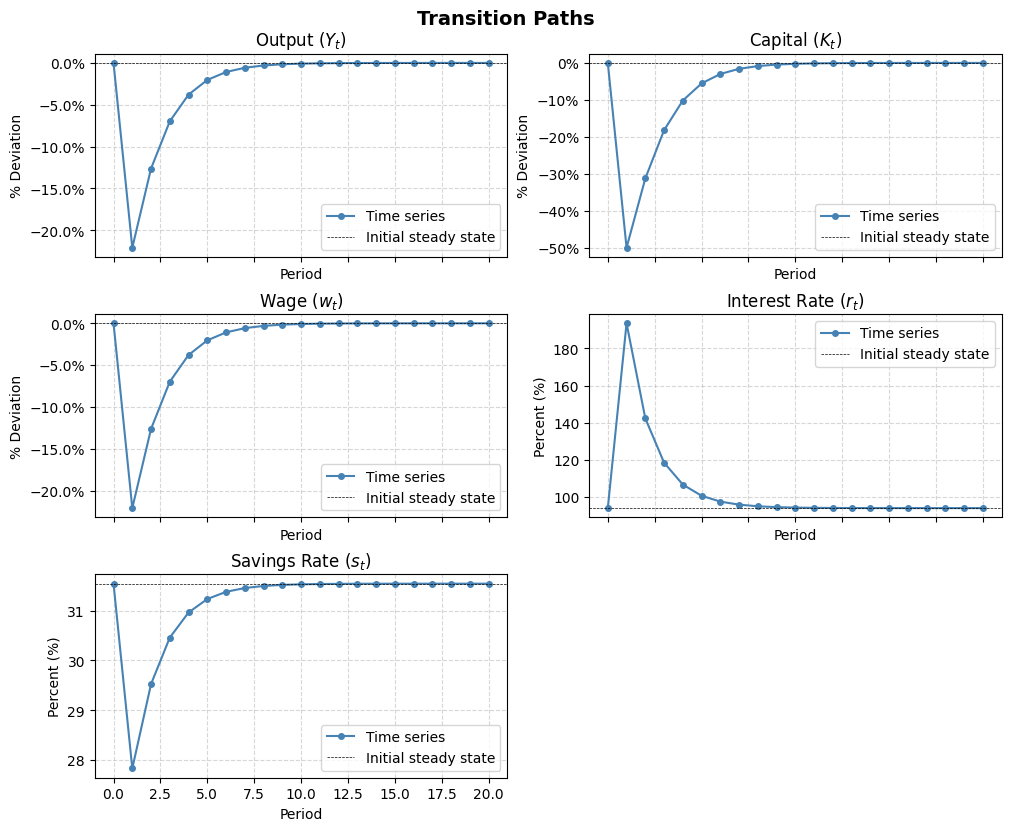

In [13]:
def plot_simulation(initial_state, simulation, new_state=None, z_series=None):
    """
    Plots transition paths for economic variables.
    """

    # Define variables to plot
    variables = ["Y", "K", "w", "r", "s"]
    plot_titles = ["Output ($Y_t$)", "Capital ($K_t$)", "Wage ($w_t$)",
                   "Interest Rate ($r_t$)", "Savings Rate ($s_t$)"]

    # Check if it's Part 6 (stochastic case)
    is_part6 = z_series is not None
    if is_part6:
        variables.insert(0, "TFP")
        plot_titles.insert(0, "Total Factor Productivity ($z_t$)")

    # Create subplots grid
    num_plots = len(variables)
    num_rows = (num_plots + 1) // 2  # Ensure rows are counted correctly
    fig, axes = plt.subplots(num_rows, 2, figsize=(10, 8), sharex=True, constrained_layout=True)
    fig.suptitle("Transition Paths", y=1.02, fontsize=14, fontweight="bold")

    # Flatten axes array for easy iteration
    axes = axes.flatten()

    # Plot styling
    plot_style_part34 = {"color": "steelblue", "marker": "o", "markersize": 4, "label": "Time series"}  # Dots for Part 3 & 4
    plot_style_part6 = {"color": "steelblue", "label": "Time series"}

    # Style for steady-state lines
    initial_state_style = {
        "color": "black", "linewidth": 0.5, "linestyle": "--", "label": "Initial steady state"
    }

    new_state_style = {
        "color": "red", "linewidth": 0.5, "linestyle": "--", "label": "New steady state"
    }

    # Loop through variables and create plots
    for i, (var, title) in enumerate(zip(variables, plot_titles)):
        ax = axes[i]

        # Handle TFP separately
        if var == "TFP":
            ax.plot(z_series, "steelblue", label="TFP ($z_t$)")
            ax.set_title(title)
            ax.set_ylabel("TFP")
            ax.grid(True, linestyle="--", alpha=0.5)
            continue  # Move to next plot

        # Get the relevant data series
        sim_series = getattr(simulation, var)

        # Select correct plot style
        plot_style = plot_style_part6 if is_part6 else plot_style_part34

        if is_part6:
            # Part 6: Plot absolute values without steady-state lines
            y_values = sim_series
            ax.set_ylabel(title.replace(" ($", "").replace("_t$)", ""))  # Clean labels
        else:
            # Compute deviations
            initial_value = getattr(initial_state, var)
            new_value = getattr(new_state, var) if new_state else None

            if var in ["Y", "K", "w"]:  # Percentage deviations for these
                y_values = (sim_series / initial_value - 1) * 100
                initial_y = 0 # Steady state reference line at 0%
                new_y = (new_value / initial_value - 1) * 100 if new_state else None
                ax.set_ylabel("% Deviation")
                ax.yaxis.set_major_formatter(PercentFormatter())  # Format as percentage
            else:  # Percentage terms r and s
                y_values = sim_series * 100
                initial_y = initial_value * 100
                new_y = new_value * 100 if new_state else None
                ax.set_ylabel("Percent (%)")

        # Plot the data
        ax.plot(y_values, **plot_style)

        # Show steady-state lines in part 3 and 4
        if not is_part6:
            ax.axhline(initial_y, **initial_state_style)
            if new_state:
                ax.axhline(new_y, **new_state_style)

        # Labels
        legend_labels = ["Time series"]
        if not is_part6:
            legend_labels.append("Initial steady state")
        if new_state:
            legend_labels.append("New steady state")

        ax.legend(legend_labels)

        # Label x-axis to Period
        ax.set_xlabel("Period")

        ax.set_title(title)
        ax.grid(True, linestyle="--", alpha=0.5)

    # Remove unused subplots
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

# Call function for part 3
plot_simulation(eq, sim)

Economic systems adjust dynamically to shocks through shifts in savings, investment, and factor prices. This simulation examines how an exogenous capital shock triggers recovery, driven by intertemporal choices and market incentives.

At $t = 1$, an exogenous shock halves the capital stock, sharply contracting output and wages due to reduced capital availability. Capital scarcity raises its marginal productivity, leading to a spike in the interest rate.

Households, optimizing intertemporally, increase savings in response to higher returns, accelerating capital accumulation. Firms gradually restore investment, facilitating recovery. As capital rebuilds, the interest rate declines, wages rise, and output converges to its steady-state level.

This transition exemplifies the OLG model’s equilibrium adjustment. The initial contraction, followed by systematic recovery, underscores the role of incentives in shaping savings behavior and capital formation, restoring long-run economic stability.


## Part 4 Pay-as-you-go Pension System

We introduce a pay-as-you-go (PAYGO) pension system, where the government collects a payroll tax `tau` from young workers and redistributes it as pensions $p_t$ to the old, maintaining a balanced budget:

$$ p_t = \tau w_t $$


### Step 1: Modify Parameters to Include PAYGO

Add the payroll tax parameter `tau`

In [14]:
par = Parameters(tau=0.1)  # tau = 0.1 for PAYGO system

### Step 2: Modify the functions to implement PAYGO

To implement the PAYGO system, we updated the euler_err(), compute_steady_state(), and simulate_olg() functions to incorporate the effects of the payroll tax and pension payments. These modifications ensure that the functions can handle both cases where τ = 0 (no pensions) and τ = 0.1(PAYGO system) within the same framework.


### Step 3: Steady-State Analysis

To assess the long-term impact of PAYGO pensions, we compute the new steady state under τ = 0.1 and compare it to the previous steady state where τ = 0.

In [15]:
# Compute and report the new steady state
eq_pension = compute_steady_state(par)
print_steady_state(eq_pension)

       STEADY STATE EQUILIBRIUM       
Capital (K):                       0.0381
Output (Y):                        0.3084
Wage (w):                          0.1974
Interest rate (r):                 2.0711
Young consumption (c_y):           0.1395
Old consumption (c_o):             0.1367
Savings rate (s):                  0.2144
Savings when young (a):            0.0381


The findings illustrate how a PAYGO system affects the economy by redistributing income from younger workers to retirees, leading to lower private savings and reduced long-term capital accumulation. As the capital stock declines, wages decrease, while interest rates rise due to the growing scarcity of capital.

### Step 4: Transition Dynamics

To examine the economy’s adjustment process, we simulate the transition over T = 20 periods.

In [16]:
T = 20
sim_olg_pension = simulate_olg(eq.K, T, eq, par)

### Step 5: Graphical Analysis

To visualize the transition, we plot the transition paths for output $Y_t$, capital $K_t$, wages $w_t$, interest rates $r_t$, and savings rates $s_t$.

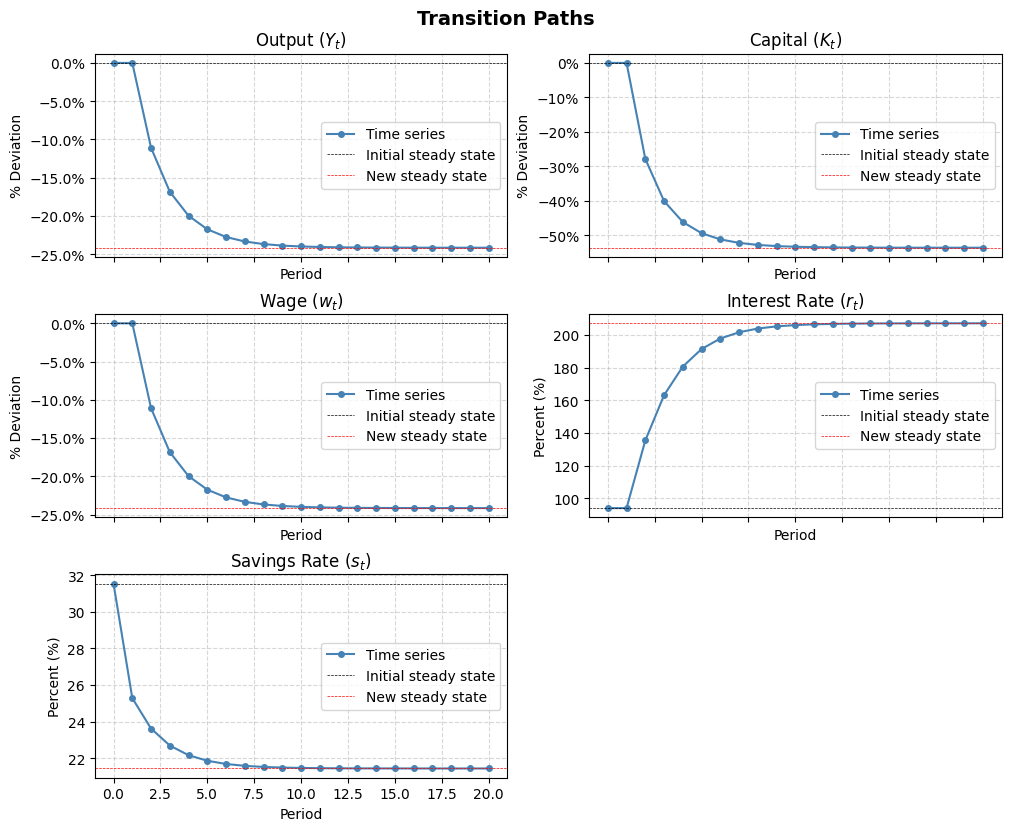

In [17]:
plot_simulation(eq, sim_olg_pension, eq_pension)

The transition paths illustrate how the introduction of a PAYGO pension system reshapes the economy over time. With the implementation of the payroll tax, young households experience a reduction in disposable income, leading them to save less. This results in a lower savings rate, which gradually affects capital accumulation. While the capital stock initially remains unchanged due to past savings decisions, the continued decline in savings leads to a steady reduction in capital over time.

Lower capital reduces labor productivity, driving down wages and output. With less capital available, the return on savings rises, increasing the interest rate. Over time, the economy converges to a new steady state under the PAYGO system.


## Part 5: TFP as an AR(1)

### Step 1: Extend the Parameters Class

To include the AR(1) process, we modify the `Parameters` class by adding attributes for $ \rho $, $ \sigma^2 $, and $ \mu $:

$$
\mu = -\frac{1}{2} \frac{\sigma^2}{1 + \rho}
$$

This ensures the expected value of TFP remains approximately 1.



In [18]:
# Update values: AR(1) Process for TFP
par.rho: float = 0.95**30
par.sigma2: float = 0.05**2
par.mu: float = -0.5 * (par.sigma2) / (1 + par.rho)  # Ensures E[z] ≈ 1

### Step 2: Discretizing Shocks Using Gauss-Hermite Quadrature
Since $ \epsilon_t $ follows a standard normal distribution, we approximate it using 5 discrete values. This is done using Gauss-Hermite quadrature:

In [19]:
# Discretization of ϵ using Gauss-Hermite quadrature
epsilon_grid, epsilon_prob = hermegauss(5)
epsilon_prob /= np.sqrt(2 * np.pi)  # Normalize probabilities

# Attach grid and probabilities to an existing Parameters instance
par.epsilon_grid = epsilon_grid
par.epsilon_prob = epsilon_prob

### Step 3: Simulating the AR(1) Process
The function simulates $ z_t $ by iterating the AR(1) process:

In [20]:
def simulate_ar1(z0, T, seed, par: Parameters):
    """
    Simulate an AR(1) process for TFP using a discrete approximation.
    """
    np.random.seed(seed) # Set the seed
    z_series = np.zeros(T+1) # Store TFP values
    z_series[0] = z0 # Initial value

    for t in range(T):
        epsilon_t = np.random.choice(par.epsilon_grid, p=par.epsilon_prob)  # Sample from predefined shocks
        log_z_next = par.mu + par.rho * np.log(z_series[t]) + np.sqrt(par.sigma2) * epsilon_t # AR(1) update

        z_series[t+1] = np.exp(log_z_next) # Convert back to level and store it

    return z_series

### Step 4: Verifying the Average Value of TFP
To confirm that $ E[z] \approx 1 $, we simulate 100,000 periods and compute the mean TFP:

In [21]:
def verify_tfp_mean(par: Parameters, T: int = 100000):
    """Verify that the long-run mean of simulated TFP ≈ 1"""

    # Simulate TFP series using AR(1) process
    z = simulate_ar1(1.0, T, seed=1234, par=par)

    # Compute the average TFP value
    avg_z = z.mean()

    # Print results
    print("=" * 50)
    print("         Verification of Average TFF")
    print("=" * 50)
    print(f"{'Simulated Average TFP:':<30}{avg_z:>16.8f}")
    print(f"{'Deviation from 1:':<30}{(avg_z - 1) * 100:>15.8f} %")
    print("=" * 50)

# Run verification
verify_tfp_mean(par, T=100000)

         Verification of Average TFF
Simulated Average TFP:              1.00004997
Deviation from 1:                  0.00499749 %


The results from our AR(1) simulation confirm that the long-run average TFP remains close to 1, as expected. The small deviation from 1 is due to the finite sample size but remains negligible, validating the correctness of our implementation.

## Part 6: OLG Model with Aggregate Risk


This section extends the overlapping generations (OLG) model by incorporating aggregate risk through a stochastic Total Factor Productivity (TFP) process. The goal is to analyze how uncertainty in TFP affects household savings and consumption decisions. The model now includes an AR(1) process for log TFP, introducing stochastic fluctuations into the economy.

### Step 1: Implement `euler_err_ar1()`

This function computes the Euler equation error when log TFP follows an AR(1) process. Since TFP is stochastic, the household's consumption-savings decision now incorporates expectations over future realizations of TFP.


In [22]:
def euler_err_ar1(k_next, k, z, par: Parameters):
    """
    Compute Euler equation error for given (k_next, k, z) under stochastic TFP.
    """

    # Compute wage
    w = (1 - par.α) * z * (k ** par.α)

    # Compute consumption when young
    c_y = (1 - par.tau) * w - k_next

    # Reject if negative consumption
    if c_y < 0:
        return np.inf


    # Compute marginal utility calculation for young consumption
    # (If consumption is zero, we set marginal utility to a very high value)
    if par.γ == 1:
        mu_cy = 1 / c_y if c_y > 0 else np.inf  # Log utility case
    else:
        mu_cy = c_y ** (-par.γ) if c_y > 0 else np.inf

    # Compute expected marginal utility of old-age consumption
    expected_mu_co = 0.0

    # Iterate over shocks to compute expectations
    for i in range(len(par.epsilon_grid)):
        epsilon_next = par.epsilon_grid[i]
        prob = par.epsilon_prob[i]

        # Compute next period TFP realization
        log_z_next = par.mu + par.rho * np.log(z) + np.sqrt(par.sigma2) * epsilon_next
        z_next = np.exp(log_z_next)

        # Compute next period wage and interest rate
        w_next = (1 - par.α) * z_next * (k_next ** par.α)
        r_next = par.α * z_next * (k_next ** (par.α - 1)) - par.δ

        # Compute pension payments
        p_next = par.tau * w_next

        # Compute old-age consumption in next period
        c_o_next = (1 + r_next) * k_next + p_next

        # Reject solutions where co_next < 0
        if c_o_next < 0:
          return np.inf

        # Compute marginal utility for old consumption
        # (If consumption is zero, we set marginal utility to a very high value)
        if par.γ == 1:
            mu_co_next = 1 / c_o_next if c_o_next > 0 else np.inf  # Log utility case
        else:
            mu_co_next = c_o_next ** (-par.γ) if c_o_next > 0 else np.inf

        # Accumulate expectation
        expected_mu_co += prob * (1 + r_next) * mu_co_next

    # Compute Euler equation error
    error = mu_cy - par.β * expected_mu_co
    return error

### Step 2: Implement `simulate_olg_ar1()`
This function simulates the transition dynamics of the OLG model with stochastic TFP, given an initial capital stock `K0` and a time series of TFP realizations. The simulation proceeds iteratively, solving for the optimal capital choice each period.


In [23]:
def simulate_olg_ar1(k0, z_series, par: Parameters):
    """
    Simulate the OLG model with stochastic TFP.
    """

    # Set number of time periods
    T = len(z_series)

    # Initialize arrays for capital stock
    K = np.zeros(T + 1)

    # Set initial capital
    K[0] = k0

    # Compute next-period capital for each period
    for t in range(T):
        z_t, K_t = z_series[t], K[t] # Current TFP and capital stock

        # Solve Euler equation for K[t+1]
        upper_bound = (1 - par.α) * z_t * (K_t ** par.α) # We set wages as a sufficient upper bound
        try:
            res = root_scalar(lambda k_next: euler_err_ar1(k_next, K_t, z_t, par), bracket=(1e-8, upper_bound), method='brentq')
            a_t = res.root
        except ValueError as e:
            raise RuntimeError(f"Root-finding failed at t={t}, K_t={K_t}, z_t={z_t}") from e

        # Update next period's capital
        K[t+1] = a_t

    # Compute output, wages, interest rate, and pensions for all periods
    Y = z_series * (K[:-1] ** par.α)
    w = (1 - par.α) * z_series * (K[:-1] ** par.α)
    r = par.α * z_series * (K[:-1] ** (par.α - 1)) - par.δ
    p = par.tau * w

    # Compute consumption and savings rate
    c_y = np.maximum((1 - par.tau) * w - K[1:], 0)
    c_o = np.maximum((1 + r) * K[:-1] + p, 0)
    s = np.where(w > 0, K[1:] / ((1 - par.tau) * w), 0.0)

    # Goods Market Clearing Check
    lhs = Y + (1 - par.δ) * K[:-1]
    rhs = c_y + c_o + K[1:]
    assert np.all(np.abs(lhs - rhs) < 1e-8), "Goods market clearing fails"

    return Simulation(K=K, Y=Y, w=w, r=r, p=p, s=s, c_o=c_o, c_y = c_y)


### Step 3: Simulate TFP Series
Using the function `simulate_ar1()`, we generate a sequence of TFP realizations over `T=100` periods. The initial value is set to the steady-state TFP level, and a random seed ensures reproducibility.


In [24]:
T = 100
z_series = simulate_ar1(1.0, T, seed=1234, par=par)

### Step 4: Simulate the OLG Economy
Starting from the steady-state capital stock, we use the simulated TFP series to compute the evolution of capital over time. This step involves solving the Euler equation numerically in each period.


In [25]:
sim2 = simulate_olg_ar1(eq_pension.K, z_series, par)

### Step 5: Extend the Plotting Function

To visualize the results, we modify the plotting function to generate a `3x2` figure with time series plots for the following variables: TFP, output, capital stock, wages, interest rate, and savings.

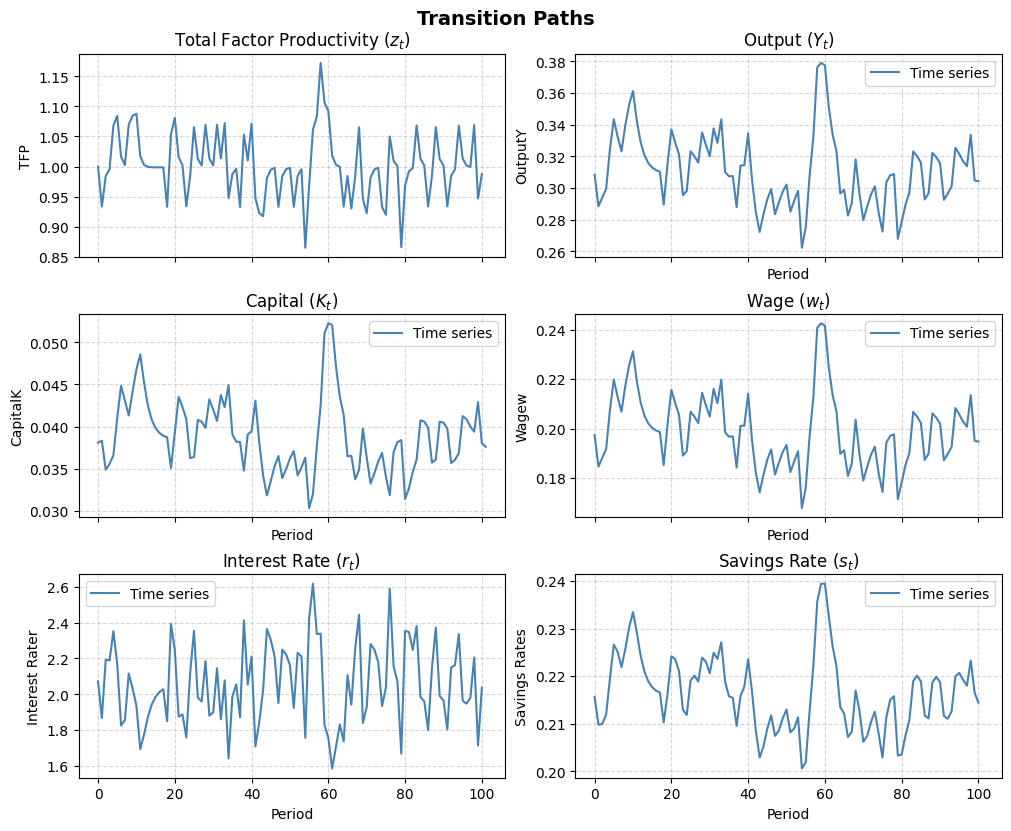

In [26]:
plot_simulation(eq_pension, sim2, z_series=z_series)

The introduction of an AR(1) process for TFP $z_t$ shows how productivity shocks persist and spread through the economy. Output $Y_t$ moves closely with TFP, as higher productivity boosts production, while lower productivity contracts it. Capital stock $K_t$ adjusts more gradually due to its predetermined nature. Positive TFP shocks increase investment, leading to temporary capital accumulation, while negative shocks slow investment and cause temporary declines rather than a continous reduction over time. Wages $w_t$ fluctuate with TFP, reflecting changes in labor productivity.  The interest rate $r_t$ varies inversely with capital, rising when capital is scarce and falling when investment increases, but also fluctuates due to ongoing economic schocks. The savings rate $s_t$ exhibits fluctuations as households adjust to changes in both productivity and expected returns on capital.  

## Part 7: Changing the volatility of TFP

In this part, we analyze how the volatility of Total Factor Productivity (TFP) affects household savings behavior. The simulation runs for 10,000 periods with varying TFP volatility across 11 values uniformly spaced in the interval [0,0.1]. The objective is to examine how changes in risk influence the average capital stock and savings rate.

### Step 1: Run the simulation with varying volatility

In [27]:
# Define the range of sigma values
sigma_values = np.linspace(0, 0.1, 11)  # 11 points from 0 to 0.1
T = 10000  # Number of periods

# Storage for results
K_deviation = np.zeros(len(sigma_values))
s_deviation = np.zeros(len(sigma_values))

# Run simulation for each sigma value
for i, sigma in enumerate(sigma_values):

    # Update model parameters for given sigma
    par.sigma2 = sigma**2  # Variance
    par.mu = -0.5 * par.sigma2 / (1 + par.rho)  # Ensures E[z] ≈ 1

    # Simulate stochastic TFP series
    z_series = simulate_ar1(1.0, T, seed = 1234, par = par)

    # Simulate OLG model with stochastic TFP
    sim3 = simulate_olg_ar1(eq_pension.K, z_series, par)

    # Compute averages across all periods
    K_avg = np.mean(sim3.K)
    s_avg = np.mean(sim3.s)

    # Compute percent deviations from steady-state values
    K_deviation[i] = ((K_avg - eq_pension.K) / eq_pension.K) * 100
    s_deviation[i] = ((s_avg - eq_pension.s) / eq_pension.s) * 100

### Step 2: Plot the average simulated capital stock and savings rate with volatility

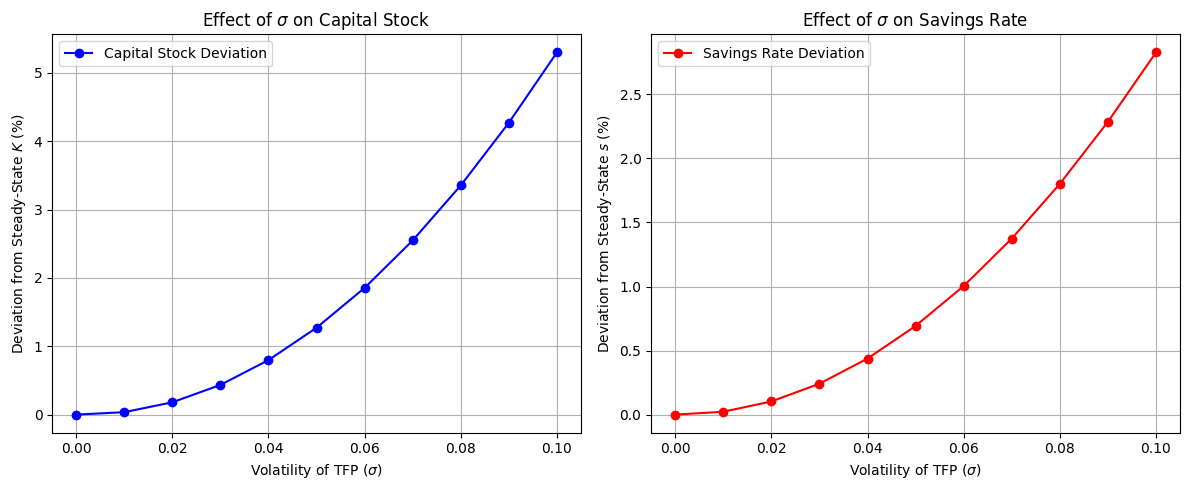

In [28]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Capital Stock Deviation
axes[0].plot(sigma_values, K_deviation, 'bo-', label="Capital Stock Deviation")
axes[0].set_title("Effect of $\\sigma$ on Capital Stock")
axes[0].set_xlabel("Volatility of TFP ($\\sigma$)")
axes[0].set_ylabel("Deviation from Steady-State $K$ (%)")
axes[0].legend()
axes[0].grid()

# Plot Savings Rate Deviation
axes[1].plot(sigma_values, s_deviation, 'ro-', label="Savings Rate Deviation")
axes[1].set_title("Effect of $\\sigma$ on Savings Rate")
axes[1].set_xlabel("Volatility of TFP ($\\sigma$)")
axes[1].set_ylabel("Deviation from Steady-State $s$ (%)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

The simulation indicates that while TFP volatility increases, households respond by saving more to protect against uncertainty. This leads to higher capital accumulation, with the effect becoming more pronounced at higher volatility levels. At first, the increase in capital is gradual, but beyond a certain point, it accelerates as households become more cautious.

The savings rate follows a similar pattern, remaining relatively stable at low volatility but rising as uncertainty grows. This reflects a stronger precautionary savings motive. While small fluctuations might appear, the overall trend suggests that higher risk leads to more saving and investment in capital.

